# DimeNet++ Hyperparameter Tuning on OMol25 Biomolecules

**Goal:** Maximize DimeNet++ performance for HOMO-LUMO gap prediction within Colab T4 GPU constraints.

**Approach:** Sequential one-at-a-time tuning, starting from cheap "free wins" and progressing to costlier architecture knobs. Each section establishes a hypothesis, runs the experiment, and decides whether to keep the change.

**Setup:**
- Train: 1000 biomolecules from `data0000.aselmdb` (80/20 train/val split)
- Test: 200 biomolecules from `data0001.aselmdb` (held-out, fixed across runs)
- Loss function: SmoothL1 (matched to SchNet's best from sweep)

## Story arc
1. **Baseline**  establish starting point with default config
2. **Free wins**  add target normalization, AdamW, scheduler, early stopping, gradient clipping, EMA (no compute cost)
3. **LR sweep**  find optimal learning rate (highest single-knob impact)
4. **Weight decay sweep**  fine-tune regularization strength
5. **Architecture exploration**  tweak `int_emb_size` / `out_emb_channels` / `num_blocks` / `cutoff`
6. **Final result**  best config combined
7. **(Optional) Scale up**  winning config on 5k or 10k molecules

**Note on defaults:** The official DimeNet++ paper uses `hidden_channels=128`, `out_emb_channels=256`, `num_blocks=4`, `lr=1e-3` with warmup + exponential decay and EMA (decay=0.999). However, those defaults target QM9 (small molecules, ~9 atoms each) on high-end GPUs. OMol25 biomolecules are much larger, so we keep `hidden_channels=64` to stay within T4 memory, and instead focus on training recipe improvements (EMA, warmup, LR) which are free or cheap.

---
## Section 0: Environment Setup

Install dependencies, restart runtime, then import everything.

In [ ]:
# Install dependencies
!pip install -q torch==2.5.0 --index-url https://download.pytorch.org/whl/cu121
!pip install -q torch_geometric
!pip install -q torch_cluster torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html
!pip install -q ase
!pip install -q --force-reinstall --no-deps "fairchem-core<2.0"
!pip install -q lmdb ase-db-backends e3nn hydra-core pymatgen submitit torchtnt

print("RESTART THE RUNTIME SESSION NOW")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 118.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 62.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 143.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 22.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 47.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.6/209.6 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# After restart, run this cell
import sys
sys.path.insert(0, '/content')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from copy import deepcopy

from torch_geometric.loader import DataLoader
from torch_geometric.nn import DimeNetPlusPlus
from fairchem.core.datasets import AseDBDataset

from read_multi_ase import find_files, process_file
from extract import get_data, split_data, mol_to_data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Verify GPU
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA L4
Memory: 23.7 GB


### Load data: 500 train + 200 test


In [ ]:
bio_sample = process_file(
    file="/content/data0000.aselmdb",
    molecule_type="biomolecules",
    max_molecules=500
)
bio_data = get_data(bio_sample)
bio_train, bio_val, _ = split_data(bio_data, val_size_pct=0.2, test_size_pct=0.0)

print(f"Train: {len(bio_train)} | Val: {len(bio_val)}")

# Compute target normalization stats from TRAIN ONLY (no leakage)
train_targets = torch.tensor([d.y.item() for d in bio_train])
y_mean = train_targets.mean().item()
y_std = train_targets.std().item()
print(f"Target stats (HOMO-LUMO gap, training set):")
print(f"  Mean: {y_mean:.4f} eV")
print(f"  Std:  {y_std:.4f} eV")
print(f"  Range: [{train_targets.min().item():.2f}, {train_targets.max().item():.2f}] eV")

# Load test data (200 biomolecules, never normalized)
bio_testing = process_file(
    file="/content/data0001.aselmdb",
    molecule_type="biomolecules",
    max_molecules=200
)
bio_test_data = get_data(bio_testing)
print(f"Test: {len(bio_test_data)}")

# Standard loaders (will be re-created per experiment as needed)
bio_train_loader = DataLoader(bio_train, batch_size=32, shuffle=True)
bio_val_loader = DataLoader(bio_val, batch_size=32)
bio_test_loader = DataLoader(bio_test_data, batch_size=32)

Processed 500 atoms
Train: 400 | Val: 100

Target stats (HOMO-LUMO gap, training set):
  Mean: 8.1988 eV
  Std:  1.9281 eV
  Range: [0.61, 12.98] eV
Processed 200 atoms
Test: 200


### Define the model class and shared training functions

In [ ]:
class DimeNetPPModel(torch.nn.Module):
    """DimeNet++ wrapper. Hyperparameters exposed for tuning experiments."""
    def __init__(self,
                 hidden_channels: int = 64,
                 num_blocks: int = 3,
                 int_emb_size: int = 64,
                 out_emb_channels: int = 128,
                 num_spherical: int = 7,
                 num_radial: int = 6,
                 cutoff: float = 5.0,
                 max_num_neighbors: int = 32):
        super().__init__()
        self.dimenet = DimeNetPlusPlus(
            hidden_channels=hidden_channels,
            out_channels=1,
            num_blocks=num_blocks,
            int_emb_size=int_emb_size,
            basis_emb_size=8,
            out_emb_channels=out_emb_channels,
            num_spherical=num_spherical,
            num_radial=num_radial,
            cutoff=cutoff,
            max_num_neighbors=max_num_neighbors,
        )
    def forward(self, data):
        return self.dimenet(data.z, data.pos, batch=data.batch)


class EMA:
    """Exponential Moving Average of model weights (used by official DimeNet++ training)."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.clone() for k, v in model.state_dict().items()}

    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k] = self.decay * self.shadow[k] + (1 - self.decay) * v

    def apply(self, model):
        """Replace model weights with EMA weights. Returns backup for restore."""
        backup = {k: v.clone() for k, v in model.state_dict().items()}
        model.load_state_dict(self.shadow)
        return backup

    def restore(self, model, backup):
        model.load_state_dict(backup)


def train_one_epoch(model, loader, optimizer, loss_fn, normalize=False, ema=None):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        pred = model(data)
        target = data.y.view(-1, 1)
        if normalize:
            target = (target - y_mean) / y_std
        loss = loss_fn(pred, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        if ema is not None:
            ema.update(model)
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, loss_fn, normalize=False):
    model.eval()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        pred = model(data)
        target = data.y.view(-1, 1)
        if normalize:
            target = (target - y_mean) / y_std
        total_loss += loss_fn(pred, target).item()
    return total_loss / len(loader)


@torch.no_grad()
def test_model(model, loader, denormalize=False):
    """Always reports MAE/RMSE in eV (denormalizes if model was trained on normalized targets)."""
    model.eval()
    total_mae = 0
    total_mse = 0
    n = 0
    for data in loader:
        data = data.to(device)
        pred = model(data)
        if denormalize:
            pred = pred * y_std + y_mean
        target = data.y.view(-1, 1)  # always in eV
        total_mae += torch.abs(pred - target).sum().item()
        total_mse += ((pred - target) ** 2).sum().item()
        n += target.size(0)
    return total_mae / n, (total_mse / n) ** 0.5


def run_training(model, optimizer, loss_fn,
                 epochs=100, patience=20,
                 use_scheduler=True, normalize=False,
                 use_ema=False, verbose=True):
    """Universal training loop: optional scheduler + early stopping + EMA + best-model save."""
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=10
        )
    ema = EMA(model, decay=0.999) if use_ema else None
    best_val = float('inf')
    patience_counter = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        tl = train_one_epoch(model, bio_train_loader, optimizer, loss_fn, normalize, ema=ema)

        # Evaluate using EMA weights if available
        if ema is not None:
            backup = ema.apply(model)
        vl = evaluate(model, bio_val_loader, loss_fn, normalize)
        if ema is not None:
            ema.restore(model, backup)

        if use_scheduler:
            scheduler.step(vl)
        train_losses.append(tl)
        val_losses.append(vl)

        if vl < best_val:
            best_val = vl
            # Save EMA weights as best if using EMA, otherwise save regular weights
            if ema is not None:
                best_state = {k: v.clone() for k, v in ema.shadow.items()}
            else:
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            lr_now = optimizer.param_groups[0]['lr']
            print(f"  Epoch {epoch+1:03d} | Train: {tl:.4f} | Val: {vl:.4f} | LR: {lr_now:.1e}")

        if patience_counter >= patience:
            if verbose:
                print(f"  Early stop at epoch {epoch+1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return np.array(train_losses), np.array(val_losses), best_val


# Central results tracker (auto-saved after every run)
all_runs = {}
RESULTS_PATH = '/content/all_runs.json'

# Load previous results if continuing a session
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        all_runs = json.load(f)
    print(f"Loaded {len(all_runs)} previous runs from disk")
else:
    print("Fresh session — no previous runs found")


def save_run(name, config, train_losses, val_losses, mae, rmse, best_val):
    all_runs[name] = {
        'config': config,
        'train_losses': train_losses.tolist() if hasattr(train_losses, 'tolist') else list(train_losses),
        'val_losses': val_losses.tolist() if hasattr(val_losses, 'tolist') else list(val_losses),
        'test_mae': float(mae),
        'test_rmse': float(rmse),
        'best_val_loss': float(best_val),
    }
    with open(RESULTS_PATH, 'w') as f:
        json.dump(all_runs, f, indent=2)
    print(f"\n[Saved run '{name}'] Test MAE: {mae:.4f} | Test RMSE: {rmse:.4f}")


print("Setup complete")

Fresh session — no previous runs found
Setup complete


---
## Section 1: Baseline

**Hypothesis:** With 2.5x more training data than our 200-mol baseline, default DimeNet++ should improve over the 3.06 eV Test MAE we got at 200 molecules but definitely still overfits because we have no regularization.

**Setup:** Default config, no tuning. This becomes our reference point.
- Adam (no weight decay), lr=1e-4
- No target normalization
- No scheduler, no early stopping
- 100 epochs

**Expected:** Test MAE around 2.5-3 eV (rough guess based on extrapolation).

Params: 392,966
Training Run 1: baseline (no tuning)
  Epoch 001 | Train: 5.3822 | Val: 4.9682 | LR: 1.0e-04
  Epoch 011 | Train: 3.0343 | Val: 2.6464 | LR: 1.0e-04
  Epoch 021 | Train: 2.6949 | Val: 1.9901 | LR: 1.0e-04
  Epoch 031 | Train: 2.4969 | Val: 2.1222 | LR: 1.0e-04
  Epoch 041 | Train: 2.2280 | Val: 1.9112 | LR: 1.0e-04
  Epoch 051 | Train: 1.7374 | Val: 1.7295 | LR: 1.0e-04
  Epoch 061 | Train: 1.6173 | Val: 2.1442 | LR: 1.0e-04
  Epoch 071 | Train: 1.5723 | Val: 1.8380 | LR: 1.0e-04
  Epoch 081 | Train: 1.7610 | Val: 1.7856 | LR: 1.0e-04
  Epoch 091 | Train: 1.4385 | Val: 1.5539 | LR: 1.0e-04
  Epoch 100 | Train: 1.4994 | Val: 1.7020 | LR: 1.0e-04

[Saved run '1_baseline'] Test MAE: 2.4350 | Test RMSE: 3.1573


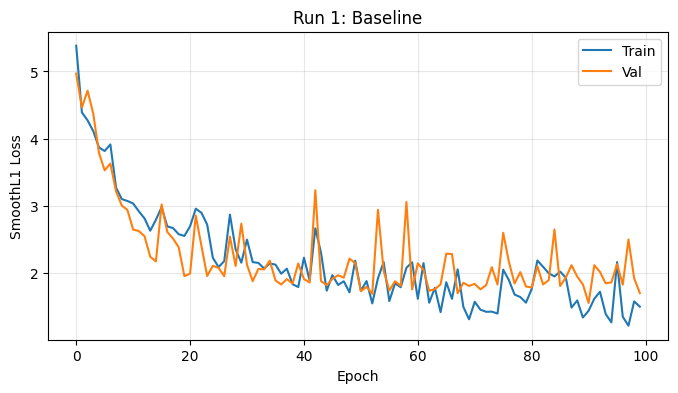

In [ ]:
# Run 1: Baseline — no tuning tricks
torch.manual_seed(42)
model = DimeNetPPModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.SmoothL1Loss()

print(f"Params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training Run 1: baseline (no tuning)")

train_losses, val_losses, best_val = run_training(
    model, optimizer, loss_fn,
    epochs=100, patience=999, # no early stopping
    use_scheduler=False,
    normalize=False,
)

mae, rmse = test_model(model, bio_test_loader, denormalize=False)

config = {
    'lr': 1e-4, 'optimizer': 'Adam', 'weight_decay': 0,
    'normalize': False, 'scheduler': False, 'early_stopping': False,
    'int_emb_size': 64, 'out_emb_channels': 128, 'num_blocks': 3,
}
save_run('1_baseline', config, train_losses, val_losses, mae, rmse, best_val)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch'); plt.ylabel('SmoothL1 Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Run 1: Baseline')
plt.show()

---
## Section 2: Free Wins (Run 2)

**Hypothesis:** Standard regularization tricks (no compute cost) will reduce overfitting and improve generalization.

**Changes from Run 1:**
- Target normalization (mean 0, std 1 from train set)
- AdamW with weight_decay=1e-4
- ReduceLROnPlateau scheduler (factor=0.5, patience=10)
- Early stopping (patience=20, restore best model)
- Gradient clipping (max_norm=10.0) for training stability
- EMA of model weights (decay=0.999) — used by the official DimeNet++ training
- Up epochs to 200 (early stop will catch convergence)

**Expected:** Meaningful improvement — typically 15-30% MAE reduction with these alone.

Training Run 2: free wins

  Epoch 001 | Train: 0.4371 | Val: 0.3349 | LR: 1.0e-04
  Epoch 011 | Train: 0.3423 | Val: 0.3266 | LR: 1.0e-04
  Epoch 021 | Train: 0.3004 | Val: 0.3217 | LR: 1.0e-04
  Epoch 031 | Train: 0.2935 | Val: 0.3216 | LR: 1.0e-04
  Epoch 041 | Train: 0.2305 | Val: 0.3229 | LR: 5.0e-05
  Early stop at epoch 47

[Saved run '2_free_wins'] Test MAE: 1.2779 | Test RMSE: 1.6843
Run 2 vs Run 1: Test MAE 2.4350 -> 1.2779 (-47.5%)


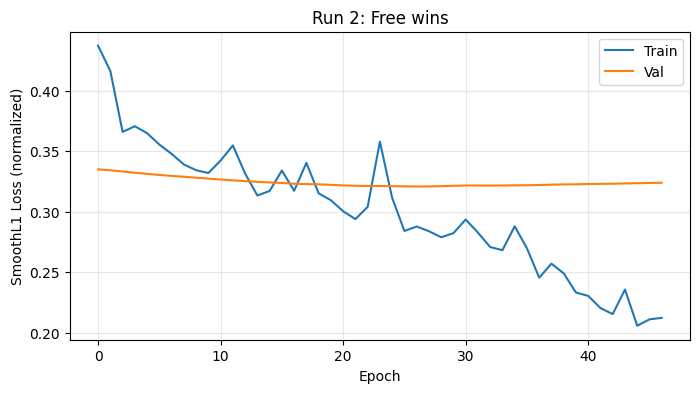

In [ ]:
# Run 2: Free wins
torch.manual_seed(42)
model = DimeNetPPModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()

print(f"Training Run 2: free wins\n")

train_losses, val_losses, best_val = run_training(
    model, optimizer, loss_fn,
    epochs=200, patience=20,
    use_scheduler=True,
    normalize=True,
    use_ema=True,
)

mae, rmse = test_model(model, bio_test_loader, denormalize=True)

config = {
    'lr': 1e-4, 'optimizer': 'AdamW', 'weight_decay': 1e-4,
    'normalize': True, 'scheduler': True, 'early_stopping': True,
    'int_emb_size': 64, 'out_emb_channels': 128, 'num_blocks': 3,
}
save_run('2_free_wins', config, train_losses, val_losses, mae, rmse, best_val)

# Compare to Run 1
delta = (all_runs['2_free_wins']['test_mae'] - all_runs['1_baseline']['test_mae']) / all_runs['1_baseline']['test_mae'] * 100
print(f"Run 2 vs Run 1: Test MAE {all_runs['1_baseline']['test_mae']:.4f} -> {mae:.4f} ({delta:+.1f}%)")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch'); plt.ylabel('SmoothL1 Loss (normalized)'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Run 2: Free wins')
plt.show()

---
## Section 3: Learning Rate Sweep

**Hypothesis:** Optimal learning rate may not be `1e-4` (which we inherited from SchNet's setup). Sweeping LR is the highest-signal single hyperparameter test.

**Sweep:** `lr ∈ {3e-5, 1e-4, 3e-4, 1e-3}` with all Run 2 settings.

**Expected:** One LR value will clearly win. Likely `3e-4` or `1e-4`.


Training 3_lr_3e-05
  Epoch 001 | Train: 0.3888 | Val: 0.3350 | LR: 3.0e-05
  Epoch 011 | Train: 0.3493 | Val: 0.3277 | LR: 3.0e-05
  Epoch 021 | Train: 0.3116 | Val: 0.3191 | LR: 3.0e-05
  Epoch 031 | Train: 0.3008 | Val: 0.3091 | LR: 3.0e-05
  Epoch 041 | Train: 0.2900 | Val: 0.2992 | LR: 3.0e-05
  Epoch 051 | Train: 0.2730 | Val: 0.2903 | LR: 3.0e-05
  Epoch 061 | Train: 0.2528 | Val: 0.2824 | LR: 3.0e-05
  Epoch 071 | Train: 0.2347 | Val: 0.2754 | LR: 3.0e-05
  Epoch 081 | Train: 0.2530 | Val: 0.2698 | LR: 3.0e-05
  Epoch 091 | Train: 0.2781 | Val: 0.2654 | LR: 3.0e-05
  Epoch 101 | Train: 0.2107 | Val: 0.2620 | LR: 3.0e-05
  Epoch 111 | Train: 0.2303 | Val: 0.2598 | LR: 3.0e-05
  Epoch 121 | Train: 0.2062 | Val: 0.2581 | LR: 3.0e-05
  Epoch 131 | Train: 0.3362 | Val: 0.2573 | LR: 3.0e-05
  Epoch 141 | Train: 0.1671 | Val: 0.2571 | LR: 3.0e-05
  Epoch 151 | Train: 0.1853 | Val: 0.2578 | LR: 1.5e-05
  Early stop at epoch 156

[Saved run '3_lr_3e-05'] Test MAE: 1.1329 | Test RMSE: 1

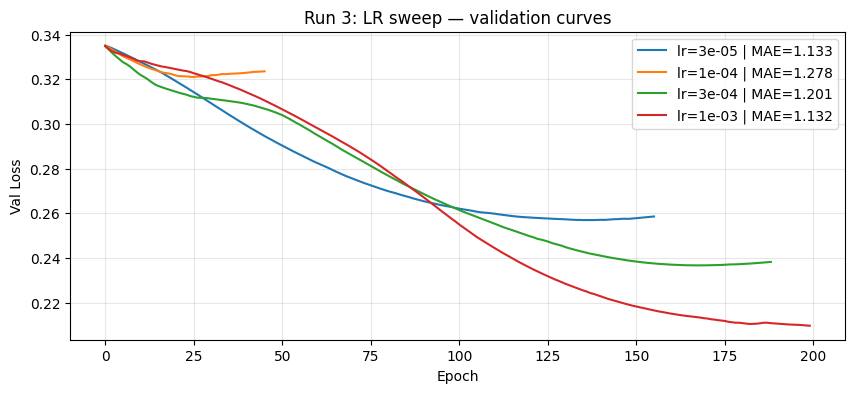

In [ ]:
# Run 3: LR sweep
lrs_to_try = [3e-5, 1e-4, 3e-4, 1e-3]

for lr in lrs_to_try:
    name = f'3_lr_{lr:.0e}'
    print(f"\n{'='*55}")
    print(f"Training {name}")
    print('='*55)

    torch.manual_seed(42)
    model = DimeNetPPModel().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.SmoothL1Loss()

    train_losses, val_losses, best_val = run_training(
        model, optimizer, loss_fn,
        epochs=200, patience=20,
        use_scheduler=True, normalize=True,
        use_ema=True, verbose=True,
    )

    mae, rmse = test_model(model, bio_test_loader, denormalize=True)

    config = {
        'lr': lr, 'optimizer': 'AdamW', 'weight_decay': 1e-4,
        'normalize': True, 'scheduler': True, 'early_stopping': True,
        'int_emb_size': 64, 'out_emb_channels': 128, 'num_blocks': 3,
    }
    save_run(name, config, train_losses, val_losses, mae, rmse, best_val)

# Pick winner
lr_runs = {k: v for k, v in all_runs.items() if k.startswith('3_lr_')}
best_lr_run = min(lr_runs.items(), key=lambda x: x[1]['test_mae'])
best_lr = best_lr_run[1]['config']['lr']

print(f"\n{'='*55}")
print(f"BEST LR: {best_lr:.0e} | Test MAE: {best_lr_run[1]['test_mae']:.4f}")
print('='*55)

# Compare LRs visually
plt.figure(figsize=(10, 4))
for name, r in lr_runs.items():
    plt.plot(r['val_losses'], label=f"lr={r['config']['lr']:.0e} | MAE={r['test_mae']:.3f}")
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Run 3: LR sweep — validation curves')
plt.show()

---
## Section 4: Weight Decay Sweep

**Hypothesis:** Default `weight_decay=1e-4` may not be optimal. Try other values to fine-tune regularization strength.

**Sweep:** `weight_decay ∈ {0, 1e-5, 1e-4, 1e-3}` with best LR from Section 3.

**Expected:** Marginal improvement; weight decay is a fine-tuning knob.

In [ ]:
# Run 4: Weight decay sweep with best LR
wds_to_try = [0, 1e-5, 1e-4, 1e-3]

for wd in wds_to_try:
    name = f'4_wd_{wd:.0e}' if wd > 0 else '4_wd_0'
    print(f"\n{'='*55}")
    print(f"Training {name} (lr={best_lr:.0e}, wd={wd})")
    print('='*55)

    torch.manual_seed(42)
    model = DimeNetPPModel().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=wd)
    loss_fn = nn.SmoothL1Loss()

    train_losses, val_losses, best_val = run_training(
        model, optimizer, loss_fn,
        epochs=200, patience=20,
        use_scheduler=True, normalize=True,
        use_ema=True, verbose=False,
    )

    mae, rmse = test_model(model, bio_test_loader, denormalize=True)

    config = {
        'lr': best_lr, 'optimizer': 'AdamW', 'weight_decay': wd,
        'normalize': True, 'scheduler': True, 'early_stopping': True,
        'int_emb_size': 64, 'out_emb_channels': 128, 'num_blocks': 3,
    }
    save_run(name, config, train_losses, val_losses, mae, rmse, best_val)
    print(f"  Test MAE: {mae:.4f} | RMSE: {rmse:.4f}")

# Pick winner
wd_runs = {k: v for k, v in all_runs.items() if k.startswith('4_wd_')}
best_wd_run = min(wd_runs.items(), key=lambda x: x[1]['test_mae'])
best_wd = best_wd_run[1]['config']['weight_decay']
print(f"\n>>> BEST WD: {best_wd} | Test MAE: {best_wd_run[1]['test_mae']:.4f}")


Training 4_wd_0 (lr=1e-03, wd=0)

[Saved run '4_wd_0'] Test MAE: 1.1676 | Test RMSE: 1.6109
  Test MAE: 1.1676 | RMSE: 1.6109

Training 4_wd_1e-05 (lr=1e-03, wd=1e-05)

[Saved run '4_wd_1e-05'] Test MAE: 1.1274 | Test RMSE: 1.5459
  Test MAE: 1.1274 | RMSE: 1.5459

Training 4_wd_1e-04 (lr=1e-03, wd=0.0001)

[Saved run '4_wd_1e-04'] Test MAE: 1.1406 | Test RMSE: 1.5770
  Test MAE: 1.1406 | RMSE: 1.5770

Training 4_wd_1e-03 (lr=1e-03, wd=0.001)

[Saved run '4_wd_1e-03'] Test MAE: 1.0920 | Test RMSE: 1.5239
  Test MAE: 1.0920 | RMSE: 1.5239

>>> BEST WD: 0.001 | Test MAE: 1.0920


---
## Section 5: Architecture Exploration

**Hypothesis:** With more training data (1000 vs 200), the model can support slightly more capacity. Also, biomolecules may benefit from deeper message passing and a larger interaction cutoff. Test cheap architecture knobs without going so big that we OOM.

**Sweep (T4-safe configs only):**
- `int_emb_size ∈ {64, 128}` (interaction block embedding width)
- `out_emb_channels ∈ {128, 192}` (output head width — keeping moderate; 256 risks OOM)
- `num_blocks ∈ {4, 6}` (deeper message passing for long-range interactions)
- `cutoff ∈ {6.0, 7.0}` (biomolecules can have important interactions beyond 5Å)

**Expected:** Modest improvement IF more capacity helps. If not, keep the smaller config from Section 4 — bigger isn't always better.

In [ ]:
# Run 5: Architecture sweep with best LR + WD
# Test cheap capacity bumps + deeper models + larger cutoff
# Keep within T4 memory limits
arch_configs = [
    {'int_emb_size': 128, 'out_emb_channels': 128, 'num_blocks': 3, 'cutoff': 5.0, 'name': '5_arch_int128'},
    {'int_emb_size': 64,  'out_emb_channels': 192, 'num_blocks': 3, 'cutoff': 5.0, 'name': '5_arch_out192'},
    {'int_emb_size': 128, 'out_emb_channels': 192, 'num_blocks': 3, 'cutoff': 5.0, 'name': '5_arch_both'},
    {'int_emb_size': 64,  'out_emb_channels': 128, 'num_blocks': 4, 'cutoff': 5.0, 'name': '5_arch_blocks4'},
    {'int_emb_size': 64,  'out_emb_channels': 128, 'num_blocks': 6, 'cutoff': 5.0, 'name': '5_arch_blocks6'},
    {'int_emb_size': 64,  'out_emb_channels': 128, 'num_blocks': 3, 'cutoff': 6.0, 'name': '5_arch_cut6'},
    {'int_emb_size': 64,  'out_emb_channels': 128, 'num_blocks': 3, 'cutoff': 7.0, 'name': '5_arch_cut7'},
]

for cfg in arch_configs:
    name = cfg['name']
    print(f"\n{'='*55}")
    print(f"Training {name} | int_emb={cfg['int_emb_size']}, out_emb={cfg['out_emb_channels']}, blocks={cfg['num_blocks']}, cutoff={cfg['cutoff']}")
    print('='*55)

    try:
        torch.manual_seed(42)
        model = DimeNetPPModel(
            int_emb_size=cfg['int_emb_size'],
            out_emb_channels=cfg['out_emb_channels'],
            num_blocks=cfg['num_blocks'],
            cutoff=cfg['cutoff'],
        ).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=best_wd)
        loss_fn = nn.SmoothL1Loss()
        n_params = sum(p.numel() for p in model.parameters())
        print(f"  Params: {n_params:,}")

        train_losses, val_losses, best_val = run_training(
            model, optimizer, loss_fn,
            epochs=250, patience=30,
            use_scheduler=True, normalize=True,
            use_ema=True, verbose=False,
        )

        mae, rmse = test_model(model, bio_test_loader, denormalize=True)

        config = {
            'lr': best_lr, 'optimizer': 'AdamW', 'weight_decay': best_wd,
            'normalize': True, 'scheduler': True, 'early_stopping': True,
            'int_emb_size': cfg['int_emb_size'],
            'out_emb_channels': cfg['out_emb_channels'],
            'num_blocks': cfg['num_blocks'], 'cutoff': cfg['cutoff'],
            'params': n_params,
        }
        save_run(name, config, train_losses, val_losses, mae, rmse, best_val)
        print(f"  Test MAE: {mae:.4f} | RMSE: {rmse:.4f}")

    except torch.cuda.OutOfMemoryError:
        print(f"OOM — skipping this config")
        torch.cuda.empty_cache()
    except Exception as e:
        print(f"Error: {e}")
        torch.cuda.empty_cache()

# Pick winner: include baseline arch from Run 4 best as comparison
arch_runs = {k: v for k, v in all_runs.items() if k.startswith('5_arch_')}
best_wd_key = min((k for k in all_runs if k.startswith('4_wd_')),
                   key=lambda k: all_runs[k]['test_mae'])
baseline_arch_mae = all_runs[best_wd_key]['test_mae']

# Defaults from baseline
best_int_emb, best_out_emb, best_num_blocks, best_cutoff = 64, 128, 3, 5.0

if arch_runs:
    best_arch_run = min(arch_runs.items(), key=lambda x: x[1]['test_mae'])
    if best_arch_run[1]['test_mae'] < baseline_arch_mae:
        print(f"BEST ARCH: {best_arch_run[0]} | Test MAE: {best_arch_run[1]['test_mae']:.4f}")
        best_int_emb = best_arch_run[1]['config']['int_emb_size']
        best_out_emb = best_arch_run[1]['config']['out_emb_channels']
        best_num_blocks = best_arch_run[1]['config']['num_blocks']
        best_cutoff = best_arch_run[1]['config']['cutoff']
    else:
        print(f"ARCH BUMP DIDN'T HELP — keeping baseline defaults")
        print(f"  Best arch run: {best_arch_run[1]['test_mae']:.4f} vs baseline: {baseline_arch_mae:.4f}")
else:
    print("All arch runs failed — using defaults")


Training 5_arch_int128 | int_emb=128, out_emb=128, blocks=3, cutoff=5.0
  Params: 419,078

[Saved run '5_arch_int128'] Test MAE: 1.1586 | Test RMSE: 1.5227
  Test MAE: 1.1586 | RMSE: 1.5227

Training 5_arch_out192 | int_emb=64, out_emb=192, blocks=3, cutoff=5.0
  Params: 656,134

[Saved run '5_arch_out192'] Test MAE: 1.1133 | Test RMSE: 1.4559
  Test MAE: 1.1133 | RMSE: 1.4559

Training 5_arch_both | int_emb=128, out_emb=192, blocks=3, cutoff=5.0
  Params: 682,246

[Saved run '5_arch_both'] Test MAE: 1.0873 | Test RMSE: 1.4948
  Test MAE: 1.0873 | RMSE: 1.4948

Training 5_arch_blocks4 | int_emb=64, out_emb=128, blocks=4, cutoff=5.0
  Params: 498,246

[Saved run '5_arch_blocks4'] Test MAE: 1.0260 | Test RMSE: 1.3844
  Test MAE: 1.0260 | RMSE: 1.3844

Training 5_arch_blocks6 | int_emb=64, out_emb=128, blocks=6, cutoff=5.0
  Params: 708,806

[Saved run '5_arch_blocks6'] Test MAE: 1.3713 | Test RMSE: 2.1294
  Test MAE: 1.3713 | RMSE: 2.1294

Training 5_arch_cut6 | int_emb=64, out_emb=128,

---
## Section 6: Final Result

Best config from all sweeps combined. This is the model we'll report as our final tuned DimeNet++ on 1000 biomolecules.

In [ ]:
# Run 6: Final model with all best settings
print(f"Final configuration:")
print(f"  Learning rate:     {best_lr:.0e}")
print(f"  Weight decay:      {best_wd}")
print(f"  int_emb_size:      {best_int_emb}")
print(f"  out_emb_channels:  {best_out_emb}")
print(f"  num_blocks:        {best_num_blocks}")
print(f"  cutoff:            {best_cutoff}")
print(f"  + AdamW, target normalization, scheduler, early stopping, grad clipping")

torch.manual_seed(42)
final_model = DimeNetPPModel(
    int_emb_size=best_int_emb,
    out_emb_channels=best_out_emb,
    num_blocks=best_num_blocks,
    cutoff=best_cutoff,
).to(device)
optimizer = torch.optim.AdamW(final_model.parameters(), lr=best_lr, weight_decay=best_wd)
loss_fn = nn.SmoothL1Loss()

print(f"\nParams: {sum(p.numel() for p in final_model.parameters()):,}")
print("Training final model...\n")

train_losses, val_losses, best_val = run_training(
    final_model, optimizer, loss_fn,
    epochs=200, patience=25,
    use_scheduler=True, normalize=True,
    use_ema=True, verbose=True,
)

mae, rmse = test_model(final_model, bio_test_loader, denormalize=True)

config = {
    'lr': best_lr, 'optimizer': 'AdamW', 'weight_decay': best_wd,
    'normalize': True, 'scheduler': True, 'early_stopping': True,
    'int_emb_size': best_int_emb, 'out_emb_channels': best_out_emb,
    'num_blocks': best_num_blocks, 'cutoff': best_cutoff,
}
save_run('6_final', config, train_losses, val_losses, mae, rmse, best_val)

print(f"\n{'='*55}")
print(f"FINAL: Test MAE = {mae:.4f} eV | Test RMSE = {rmse:.4f} eV")
print('='*55)

Final configuration:
  Learning rate:     1e-03
  Weight decay:      0.001
  int_emb_size:      64
  out_emb_channels:  128
  num_blocks:        4
  cutoff:            5.0
  + AdamW, target normalization, scheduler, early stopping, grad clipping

Params: 498,246
Training final model...

  Epoch 001 | Train: 1.0735 | Val: 0.3324 | LR: 1.0e-03
  Epoch 011 | Train: 0.3737 | Val: 0.3211 | LR: 1.0e-03
  Epoch 021 | Train: 0.3128 | Val: 0.3173 | LR: 1.0e-03
  Epoch 031 | Train: 0.3090 | Val: 0.3129 | LR: 1.0e-03
  Epoch 041 | Train: 0.1070 | Val: 0.3080 | LR: 1.0e-03
  Epoch 051 | Train: 0.0255 | Val: 0.3012 | LR: 1.0e-03
  Epoch 061 | Train: 0.0164 | Val: 0.2945 | LR: 1.0e-03
  Epoch 071 | Train: 0.0097 | Val: 0.2893 | LR: 1.0e-03
  Epoch 081 | Train: 0.0085 | Val: 0.2858 | LR: 1.0e-03
  Epoch 091 | Train: 0.0102 | Val: 0.2823 | LR: 1.0e-03
  Epoch 101 | Train: 0.0127 | Val: 0.2761 | LR: 1.0e-03
  Epoch 111 | Train: 0.0075 | Val: 0.2661 | LR: 1.0e-03
  Epoch 121 | Train: 0.0040 | Val: 0.255

In [ ]:
# Insurance run — same exact config but generous training time because val was still dropping

torch.manual_seed(42)
insurance_model = DimeNetPPModel(
    int_emb_size=best_int_emb,
    out_emb_channels=best_out_emb,
    num_blocks=best_num_blocks,
    cutoff=best_cutoff,
).to(device)
optimizer = torch.optim.AdamW(insurance_model.parameters(), lr=best_lr, weight_decay=best_wd)
loss_fn = nn.SmoothL1Loss()

train_losses_ins, val_losses_ins, best_val_ins = run_training(
    insurance_model, optimizer, loss_fn,
    epochs=400, patience=50,    # generous
    use_scheduler=True, normalize=True,
    use_ema=True, verbose=True,
)

mae_ins, rmse_ins = test_model(insurance_model, bio_test_loader, denormalize=True)

config_ins = {
    'lr': best_lr, 'optimizer': 'AdamW', 'weight_decay': best_wd,
    'normalize': True, 'scheduler': True, 'early_stopping': True,
    'int_emb_size': best_int_emb, 'out_emb_channels': best_out_emb,
    'num_blocks': best_num_blocks, 'cutoff': best_cutoff,
    'epochs_max': 400, 'patience': 50, 'note': 'extended training',
}
save_run('6_final_extended', config_ins, train_losses_ins, val_losses_ins, mae_ins, rmse_ins, best_val_ins)

print(f"\n{'='*55}")
print(f"EXTENDED:  Test MAE = {mae_ins:.4f} eV | RMSE = {rmse_ins:.4f}")
print(f"ORIGINAL:  Test MAE = {all_runs['6_final']['test_mae']:.4f} eV | RMSE = {all_runs['6_final']['test_rmse']:.4f}")
print('='*55)

if mae_ins < all_runs['6_final']['test_mae']:
    improvement = (all_runs['6_final']['test_mae'] - mae_ins) / all_runs['6_final']['test_mae'] * 100
    print(f"Extended training improved by {improvement:.1f}% — use this as headline")
else:
    print(f"Extended training didn't help — original is fine")

  Epoch 001 | Train: 1.0735 | Val: 0.3324 | LR: 1.0e-03
  Epoch 011 | Train: 0.3737 | Val: 0.3211 | LR: 1.0e-03
  Epoch 021 | Train: 0.3080 | Val: 0.3173 | LR: 1.0e-03
  Epoch 031 | Train: 0.2701 | Val: 0.3137 | LR: 1.0e-03
  Epoch 041 | Train: 0.1269 | Val: 0.3087 | LR: 1.0e-03
  Epoch 051 | Train: 0.0486 | Val: 0.3016 | LR: 1.0e-03
  Epoch 061 | Train: 0.0100 | Val: 0.2935 | LR: 1.0e-03
  Epoch 071 | Train: 0.0070 | Val: 0.2863 | LR: 1.0e-03
  Epoch 081 | Train: 0.0142 | Val: 0.2803 | LR: 1.0e-03
  Epoch 091 | Train: 0.0051 | Val: 0.2762 | LR: 1.0e-03
  Epoch 101 | Train: 0.0034 | Val: 0.2710 | LR: 1.0e-03
  Epoch 111 | Train: 0.0013 | Val: 0.2630 | LR: 1.0e-03
  Epoch 121 | Train: 0.0096 | Val: 0.2532 | LR: 1.0e-03
  Epoch 131 | Train: 0.0037 | Val: 0.2426 | LR: 1.0e-03
  Epoch 141 | Train: 0.0029 | Val: 0.2328 | LR: 1.0e-03
  Epoch 151 | Train: 0.0020 | Val: 0.2248 | LR: 1.0e-03
  Epoch 161 | Train: 0.0011 | Val: 0.2189 | LR: 1.0e-03
  Epoch 171 | Train: 0.0019 | Val: 0.2146 | LR: 

---
## Section 8 (Optional): Scale Up to 5000 or 10000 Molecules


Take the winning config from Section 6 and train on more data.

**Expected:** Further MAE improvement from data scale.

This will take ~30-60 minutes for 5000 molecules, ~60-90 minutes for 10000.

In [ ]:
# Run 7: Scale up — same winning config, more data
SCALE_UP_TO = 5000   # change to 10000 if you have time

print(f"Scaling up to {SCALE_UP_TO} biomolecules...")
bio_sample_big = process_file(
    file="/content/data0000.aselmdb",
    molecule_type="biomolecules",
    max_molecules=SCALE_UP_TO,
)
bio_data_big = get_data(bio_sample_big)
bio_train_big, bio_val_big, _ = split_data(bio_data_big, val_size_pct=0.2, test_size_pct=0.0)

# Re-compute target stats for new training set
train_targets_big = torch.tensor([d.y.item() for d in bio_train_big])
y_mean_big = train_targets_big.mean().item()
y_std_big = train_targets_big.std().item()

bio_train_loader_big = DataLoader(bio_train_big, batch_size=32, shuffle=True)
bio_val_loader_big = DataLoader(bio_val_big, batch_size=32)

print(f"Train: {len(bio_train_big)} | Val: {len(bio_val_big)}")
print(f"y_mean: {y_mean_big:.4f}, y_std: {y_std_big:.4f}")

# Inline training loop for the bigger dataset
torch.manual_seed(42)
big_model = DimeNetPPModel(
    int_emb_size=best_int_emb,
    out_emb_channels=best_out_emb,
    num_blocks=best_num_blocks,
    cutoff=best_cutoff,
).to(device)
optimizer = torch.optim.AdamW(big_model.parameters(), lr=best_lr, weight_decay=best_wd)
loss_fn = nn.SmoothL1Loss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

best_val = float('inf')
best_state = None
patience_counter = 0
big_train_losses, big_val_losses = [], []
ema_big = EMA(big_model, decay=0.999)

for epoch in range(400):
    # Train
    big_model.train()
    tl_total = 0
    for data in bio_train_loader_big:
        data = data.to(device)
        optimizer.zero_grad()
        pred = big_model(data)
        target = (data.y.view(-1, 1) - y_mean_big) / y_std_big
        loss = loss_fn(pred, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(big_model.parameters(), max_norm=10.0)
        optimizer.step()
        ema_big.update(big_model)
        tl_total += loss.item()
    tl = tl_total / len(bio_train_loader_big)

    # Val (using EMA weights)
    backup = ema_big.apply(big_model)
    big_model.eval()
    vl_total = 0
    with torch.no_grad():
        for data in bio_val_loader_big:
            data = data.to(device)
            pred = big_model(data)
            target = (data.y.view(-1, 1) - y_mean_big) / y_std_big
            vl_total += loss_fn(pred, target).item()
    vl = vl_total / len(bio_val_loader_big)
    ema_big.restore(big_model, backup)
    scheduler.step(vl)

    big_train_losses.append(tl)
    big_val_losses.append(vl)

    if vl < best_val:
        best_val = vl
        best_state = {k: v.clone() for k, v in ema_big.shadow.items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"  Epoch {epoch+1:03d} | Train: {tl:.4f} | Val: {vl:.4f}")
    if patience_counter >= 50:
        print(f"  Early stop at epoch {epoch+1}")
        break

big_model.load_state_dict(best_state)

# Test (denormalize using big stats since model was trained on big-norm)
big_model.eval()
total_mae = 0; total_mse = 0; n = 0
with torch.no_grad():
    for data in bio_test_loader:
        data = data.to(device)
        pred = big_model(data) * y_std_big + y_mean_big
        target = data.y.view(-1, 1)
        total_mae += torch.abs(pred - target).sum().item()
        total_mse += ((pred - target) ** 2).sum().item()
        n += target.size(0)

scale_mae = total_mae / n
scale_rmse = (total_mse / n) ** 0.5

config = {
    'lr': best_lr, 'optimizer': 'AdamW', 'weight_decay': best_wd,
    'normalize': True, 'scheduler': True, 'early_stopping': True,
    'int_emb_size': best_int_emb, 'out_emb_channels': best_out_emb,
    'num_blocks': best_num_blocks, 'cutoff': best_cutoff, 'training_size': SCALE_UP_TO,
}
save_run(f'7_scale_{SCALE_UP_TO}', config,
         np.array(big_train_losses), np.array(big_val_losses),
         scale_mae, scale_rmse, best_val)

print(f"SCALED RESULT ({SCALE_UP_TO} mols): Test MAE = {scale_mae:.4f} | Test RMSE = {scale_rmse:.4f}")

Scaling up to 5000 biomolecules...
Processed 5000 atoms
Train: 4000 | Val: 1000
y_mean: 8.2385, y_std: 1.8347
  Epoch 001 | Train: 0.8246 | Val: 0.3861
  Epoch 011 | Train: 0.2766 | Val: 0.3408
  Epoch 021 | Train: 0.1584 | Val: 0.2708
  Epoch 031 | Train: 0.0779 | Val: 0.2407
  Epoch 041 | Train: 0.0397 | Val: 0.2414
  Epoch 051 | Train: 0.0099 | Val: 0.2409
  Epoch 061 | Train: 0.0013 | Val: 0.2406
  Epoch 071 | Train: 0.0004 | Val: 0.2411
  Epoch 081 | Train: 0.0002 | Val: 0.2414
  Epoch 091 | Train: 0.0001 | Val: 0.2414
  Early stop at epoch 95

[Saved run '7_scale_5000'] Test MAE: 0.9392 | Test RMSE: 1.3462
SCALED RESULT (5000 mols): Test MAE = 0.9392 | Test RMSE = 1.3462


In [ ]:
# Diagnostic: check the actual format of homo_lumo_gap values
import numpy as np

count_single = 0
count_list_equal = 0
count_list_different = 0
samples_different = []
unexpected = []

# bio_sample is a numpy array of (N, 1) shape with atoms objects
n_to_check = min(1000, len(bio_sample))

for i in range(n_to_check):
    try:
        atoms = bio_sample[i, 0]
        raw = atoms.info.get("homo_lumo_gap")

        if isinstance(raw, (list, tuple, np.ndarray)):
            arr = np.atleast_1d(raw)
            if len(arr) == 2:
                if abs(float(arr[0]) - float(arr[1])) < 0.001:
                    count_list_equal += 1
                else:
                    count_list_different += 1
                    if len(samples_different) < 5:
                        samples_different.append((float(arr[0]), float(arr[1])))
            elif len(arr) == 1:
                count_single += 1
            else:
                unexpected.append((len(arr), arr))
        else:
            count_single += 1
    except Exception as e:
        print(f"Error at index {i}: {e}")
        break

total = count_single + count_list_equal + count_list_different
print(f"Sampled {total}/{n_to_check} molecules from bio_sample:")
print(f"  Single value:               {count_single}")
print(f"  Two-value (α=β, closed-shell): {count_list_equal}")
print(f"  Two-value (α≠β, open-shell):   {count_list_different}")

if samples_different:
    print(f"\nExamples of differing α/β gaps:")
    for alpha, beta in samples_different:
        print(f"  α={alpha:.4f}, β={beta:.4f}, |diff|={abs(alpha-beta):.4f}")

if unexpected:
    print(f"\nUnexpected formats: {len(unexpected)}")
    for length, arr in unexpected[:3]:
        print(f"  Length {length}: {arr}")

Sampled 500/500 molecules from bio_sample:
  Single value:               473
  Two-value (α=β, closed-shell): 0
  Two-value (α≠β, open-shell):   27

Examples of differing α/β gaps:
  α=1.9694, β=6.6925, |diff|=4.7231
  α=2.5688, β=10.5810, |diff|=8.0122
  α=10.5100, β=6.3591, |diff|=4.1510
  α=8.1914, β=6.3643, |diff|=1.8271
  α=11.4741, β=4.6486, |diff|=6.8255


In [ ]:
# Run 7: Scale up — same winning config, more data
SCALE_UP_TO = 10000   # change to 10000 if you have time

print(f"Scaling up to {SCALE_UP_TO} biomolecules...")
bio_sample_big = process_file(
    file="/content/data0000.aselmdb",
    molecule_type="biomolecules",
    max_molecules=SCALE_UP_TO,
)
bio_data_big = get_data(bio_sample_big)
bio_train_big, bio_val_big, _ = split_data(bio_data_big, val_size_pct=0.2, test_size_pct=0.0)

# Re-compute target stats for new training set
train_targets_big = torch.tensor([d.y.item() for d in bio_train_big])
y_mean_big = train_targets_big.mean().item()
y_std_big = train_targets_big.std().item()

bio_train_loader_big = DataLoader(bio_train_big, batch_size=32, shuffle=True)
bio_val_loader_big = DataLoader(bio_val_big, batch_size=32)

print(f"Train: {len(bio_train_big)} | Val: {len(bio_val_big)}")
print(f"y_mean: {y_mean_big:.4f}, y_std: {y_std_big:.4f}")

# Inline training loop for the bigger dataset
torch.manual_seed(42)
big_model = DimeNetPPModel(
    int_emb_size=best_int_emb,
    out_emb_channels=best_out_emb,
    num_blocks=best_num_blocks,
    cutoff=best_cutoff,
).to(device)
optimizer = torch.optim.AdamW(big_model.parameters(), lr=best_lr, weight_decay=best_wd)
loss_fn = nn.SmoothL1Loss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

best_val = float('inf')
best_state = None
patience_counter = 0
big_train_losses, big_val_losses = [], []
ema_big = EMA(big_model, decay=0.999)

for epoch in range(400):
    # Train
    big_model.train()
    tl_total = 0
    for data in bio_train_loader_big:
        data = data.to(device)
        optimizer.zero_grad()
        pred = big_model(data)
        target = (data.y.view(-1, 1) - y_mean_big) / y_std_big
        loss = loss_fn(pred, target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(big_model.parameters(), max_norm=10.0)
        optimizer.step()
        ema_big.update(big_model)
        tl_total += loss.item()
    tl = tl_total / len(bio_train_loader_big)

    # Val (using EMA weights)
    backup = ema_big.apply(big_model)
    big_model.eval()
    vl_total = 0
    with torch.no_grad():
        for data in bio_val_loader_big:
            data = data.to(device)
            pred = big_model(data)
            target = (data.y.view(-1, 1) - y_mean_big) / y_std_big
            vl_total += loss_fn(pred, target).item()
    vl = vl_total / len(bio_val_loader_big)
    ema_big.restore(big_model, backup)
    scheduler.step(vl)

    big_train_losses.append(tl)
    big_val_losses.append(vl)

    if vl < best_val:
        best_val = vl
        best_state = {k: v.clone() for k, v in ema_big.shadow.items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch % 10 == 0:
        print(f"  Epoch {epoch+1:03d} | Train: {tl:.4f} | Val: {vl:.4f}")
    if patience_counter >= 50:
        print(f"  Early stop at epoch {epoch+1}")
        break

big_model.load_state_dict(best_state)

# Test (denormalize using big stats since model was trained on big-norm)
big_model.eval()
total_mae = 0; total_mse = 0; n = 0
with torch.no_grad():
    for data in bio_test_loader:
        data = data.to(device)
        pred = big_model(data) * y_std_big + y_mean_big
        target = data.y.view(-1, 1)
        total_mae += torch.abs(pred - target).sum().item()
        total_mse += ((pred - target) ** 2).sum().item()
        n += target.size(0)

scale_mae = total_mae / n
scale_rmse = (total_mse / n) ** 0.5

config = {
    'lr': best_lr, 'optimizer': 'AdamW', 'weight_decay': best_wd,
    'normalize': True, 'scheduler': True, 'early_stopping': True,
    'int_emb_size': best_int_emb, 'out_emb_channels': best_out_emb,
    'num_blocks': best_num_blocks, 'cutoff': best_cutoff, 'training_size': SCALE_UP_TO,
}
save_run(f'7_scale_{SCALE_UP_TO}', config,
         np.array(big_train_losses), np.array(big_val_losses),
         scale_mae, scale_rmse, best_val)

print(f"SCALED RESULT ({SCALE_UP_TO} mols): Test MAE = {scale_mae:.4f} | Test RMSE = {scale_rmse:.4f}")

Scaling up to 10000 biomolecules...
Processed 10000 atoms
Train: 8000 | Val: 2000
y_mean: 8.1972, y_std: 1.8489
  Epoch 001 | Train: 0.4391 | Val: 0.3537
  Epoch 011 | Train: 0.2062 | Val: 0.2257
  Epoch 021 | Train: 0.1229 | Val: 0.1974
  Epoch 031 | Train: 0.0799 | Val: 0.2007
  Epoch 041 | Train: 0.0198 | Val: 0.2060
  Epoch 051 | Train: 0.0054 | Val: 0.2098
  Epoch 061 | Train: 0.0026 | Val: 0.2124
  Epoch 071 | Train: 0.0017 | Val: 0.2143
  Early stop at epoch 75

[Saved run '7_scale_10000'] Test MAE: 0.9028 | Test RMSE: 1.3488
SCALED RESULT (10000 mols): Test MAE = 0.9028 | Test RMSE = 1.3488


---
## Download Results

Save everything for the presentation.

In [ ]:
from google.colab import files

# Download results JSON
files.download('/content/all_runs.json')

# Download summary plot if it exists
if os.path.exists('/content/tuning_summary.png'):
    files.download('/content/tuning_summary.png')

print("Downloads triggered.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads triggered.
